In [1]:
import pandas as pd    
import matplotlib.pyplot as plt      
import seaborn as sns

In [2]:
df = pd.read_csv("Cleaned_Dataset.csv")

df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [4]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

df["YearMonth"] = df["Date"].dt.to_period("M").astype(str)

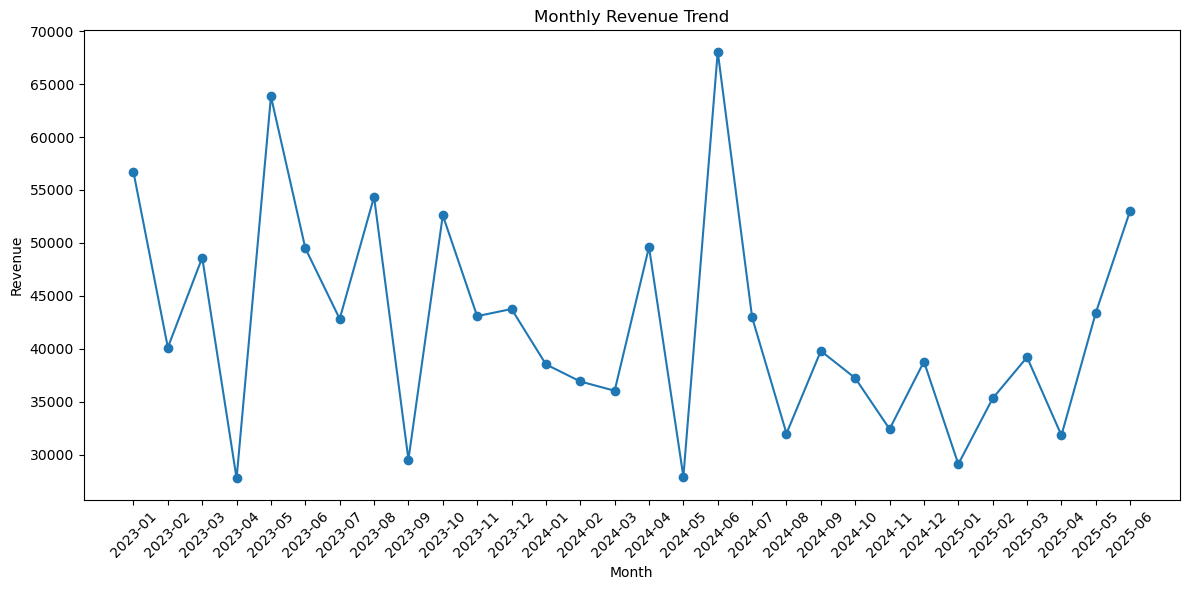

In [5]:
monthly_revenue = (
    df.groupby("YearMonth")["TotalPrice"].sum().reset_index()
)

plt.figure(figsize=(12,6))

plt.plot(monthly_revenue["YearMonth"],
        monthly_revenue["TotalPrice"], 
        marker="o")

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

Insight:

Monthly revenue shows significant fluctuations over time, with the highest peak occurring in May 2024 at approximately 68K, while several months recorded revenue below 35K.

So What?

The large fluctuations indicate inconsistent monthly performance and suggest that revenue may be influenced by seasonal or operational factors.

Recommended Action:

Investigate the causes of peak and low-performing months and use these patterns to improve sales forecasting and planning.

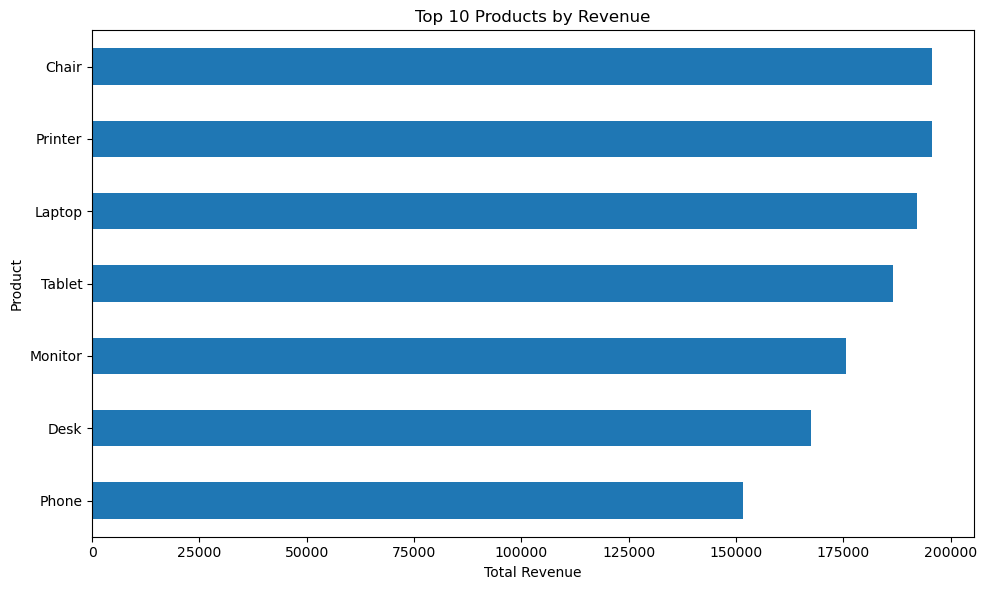

In [6]:
# Top 10 Products by Revenue

top_products = (
    df.groupby("Product")["TotalPrice"].sum().sort_values(ascending=False).head(10)
)

plt.figure(figsize=(10, 6))

top_products.sort_values().plot(kind="barh")

plt.title("Top 10 Products by Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

Insight:

Chair and Printer generate the highest revenue among the products, each contributing approximately 195K, while Phone generates the lowest revenue among the top products at around 150K.

So What?

A small group of products contributes significantly to overall revenue, making their performance important to the business.

Recommended Action:

Maintain sufficient inventory for high-revenue products and develop targeted promotions to improve the performance of lower-ranked products.

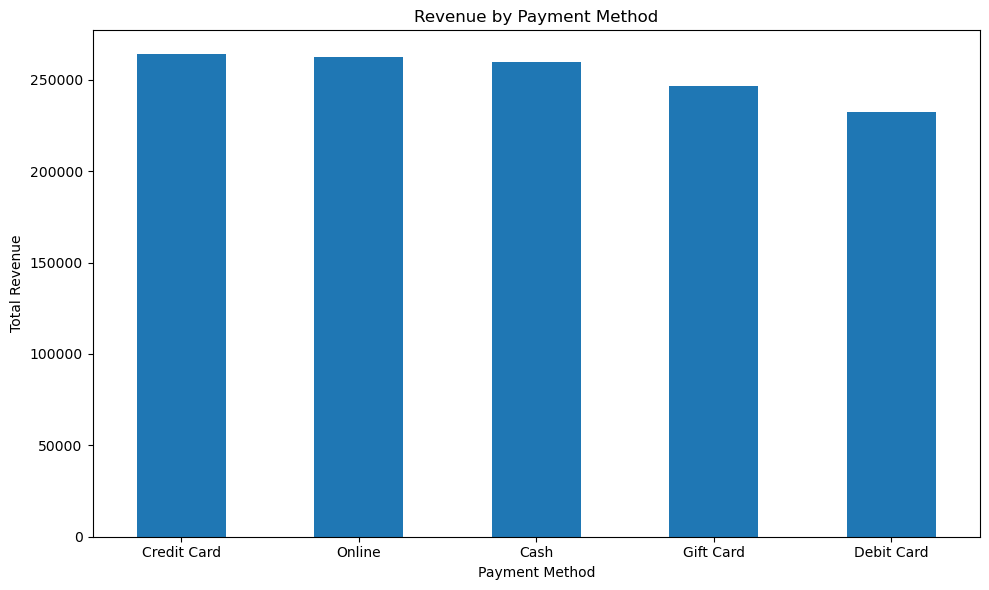

In [14]:
# Revenue by Payment Method

payment_revenue = (
    df.groupby("PaymentMethod")["TotalPrice"].sum().sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

payment_revenue.plot(kind="bar")

plt.title("Revenue by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Total Revenue")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Insight:

Credit Card and Online payments generate the highest revenue, while Debit Card generates the lowest revenue among the available payment methods.

So What?

Customers show strong preference for digital payment methods, particularly Credit Card and Online payments.

Recommended Action:

Continue supporting digital payment channels and optimize the customer checkout experience around the most frequently used methods.

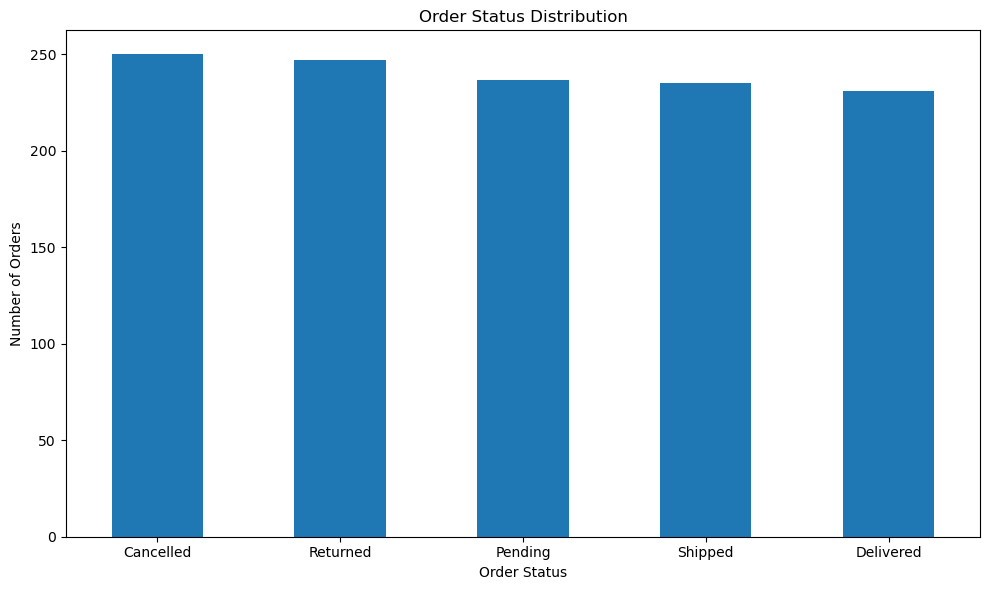

In [8]:
# Order Status Analysis

order_status = df["OrderStatus"].value_counts()

plt.figure(figsize=(10, 6))

order_status.plot(kind="bar")

plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Insight:

Cancelled orders represent the largest order-status category, with approximately 250 orders, followed closely by Returned and Pending orders.

So What?

The relatively high number of cancelled and returned orders may indicate issues in the ordering, fulfillment, or customer experience processes.

Recommended Action:

Investigate the main reasons behind cancellations and returns and implement measures to improve order completion and customer satisfaction.

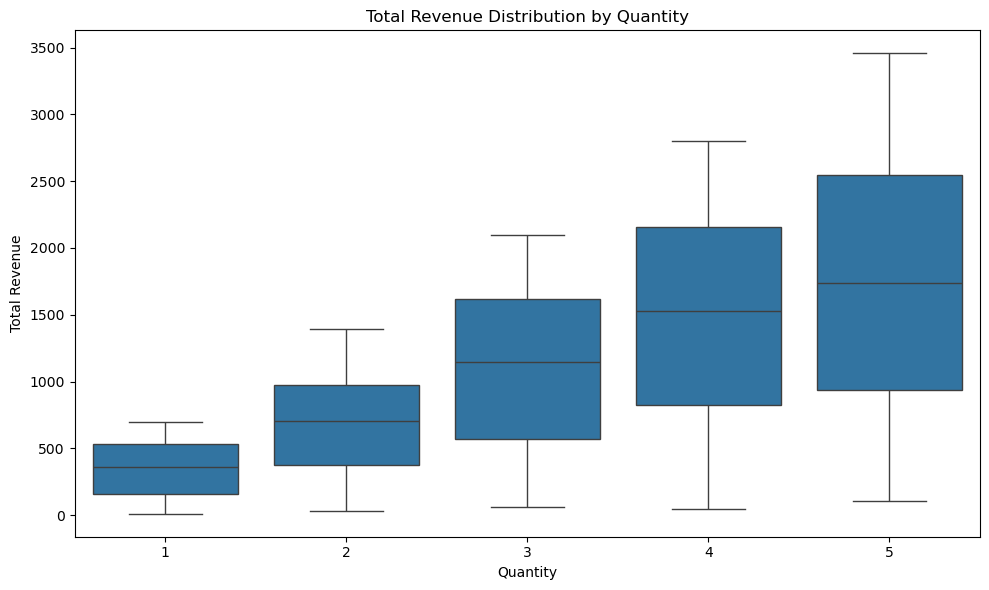

In [22]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Quantity",
    y="TotalPrice"
)

plt.title("Total Revenue Distribution by Quantity")
plt.xlabel("Quantity")
plt.ylabel("Total Revenue")

plt.tight_layout()
plt.show()

Insight:

Total revenue generally increases as order quantity increases, while higher quantities show a wider range of order values and more high-value orders.

So What?

Larger-quantity purchases have the potential to generate higher order values and contribute more significantly to overall revenue.

Recommended Action:

Encourage larger purchases through bundle offers, volume discounts, and cross-selling strategies.

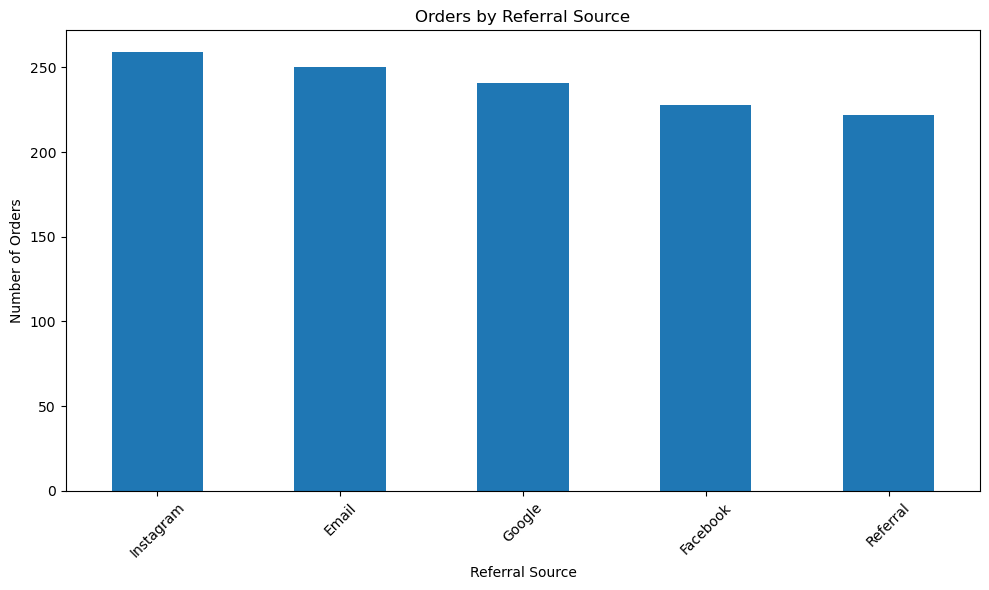

In [15]:
# Referral Source Analysis

referral_source = df["ReferralSource"].value_counts()

plt.figure(figsize=(10, 6))

referral_source.plot(kind="bar")

plt.title("Orders by Referral Source")
plt.xlabel("Referral Source")
plt.ylabel("Number of Orders")


plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Insight:

Instagram generates the highest number of orders with approximately 259 orders, followed by Email and Google.

So What?

Instagram appears to be the strongest customer acquisition channel among the analyzed referral sources.

Recommended Action:

Invest more in Instagram campaigns while monitoring conversion rates to determine whether increased traffic translates into profitable sales.

# Executive Summary

The analysis provides an overview of sales performance across revenue,
products, payment methods, order statuses, purchasing quantities, and
referral sources.

The visualizations highlight important patterns in the dataset, including
monthly revenue fluctuations, differences in product performance, customer
payment preferences, order status distribution, and the impact of quantity
on order value.

Overall, the analysis identifies several opportunities to improve revenue
performance, reduce cancelled orders, and strengthen customer acquisition
through high-performing referral channels.

# Business Recommendations

Based on the analysis, the following recommendations are proposed:

1. Investigate the reasons behind cancelled and returned orders to identify
   operational or customer experience issues.

2. Prioritize high-revenue products in inventory planning and promotional
   campaigns to maintain strong sales performance.

3. Continue optimizing digital payment methods, particularly Credit Card
   and Online payments, to provide a convenient checkout experience.

4. Analyze monthly revenue fluctuations to identify seasonal patterns and
   improve sales forecasting and resource planning.

5. Strengthen marketing activities through high-performing referral
   channels, especially Instagram.

6. Encourage larger purchases through bundle offers, volume discounts,
   and cross-selling strategies to increase average order value.

7. Monitor the performance of lower-performing products and referral
   channels to identify opportunities for improvement.

# Conclusion

This project demonstrates how Python-based data visualization can transform
sales data into clear and actionable business insights.

By combining appropriate visualizations with business-focused
interpretation, the analysis goes beyond simply presenting numbers and
helps identify trends, opportunities, and potential areas for improvement.

The project demonstrates the importance of using data visualization to
support data-driven decision-making and communicate insights effectively
to business stakeholders.